# Demo notebook for MapGlue on a single pair of images

In [2]:
import cv2
import torch
import matplotlib.pyplot as plt
import visualize
# Load the TorchScript model
model = torch.jit.load('./weights/fastmapglue_model.pt')
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


## map-visible image pair matching

In [3]:
# Load example images
image0 = cv2.imread('./assets/map-visible/L2.png')
image1 = cv2.imread('./assets/map-visible/R2.png')

# Convert BGR to RGB
image0 = cv2.cvtColor(image0, cv2.COLOR_BGR2RGB)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

# Convert numpy arrays to torch.Tensor
image0 = torch.from_numpy(image0)
image1 = torch.from_numpy(image1)
num_keypoints = torch.tensor(2048) # Defaults to 2048

# Run inference
points_tensor = model(image0, image1, num_keypoints)
points0 = points_tensor[:, :2]
points1 = points_tensor[:, 2:]

In [4]:
# Mask outliers using RANSAC (Homography or Fundamental Matrix)
inlier_method = 'H' # F: Fundamental Matrix, H: Homography 
if inlier_method == 'F':
    F, inlier_mask = cv2.findFundamentalMat(points0.cpu().numpy(), points1.cpu().numpy(), cv2.USAC_MAGSAC, ransacReprojThreshold=1, maxIters=10000, confidence=0.9999)
elif inlier_method == 'H':
    H_pred, inlier_mask = cv2.findHomography(points0.cpu().numpy(), points1.cpu().numpy(), cv2.USAC_MAGSAC, ransacReprojThreshold=3, maxIters=10000, confidence=0.9999)

inlier_mask = inlier_mask.ravel() > 0
mkpts0 = points0[inlier_mask]
mkpts1 = points1[inlier_mask]

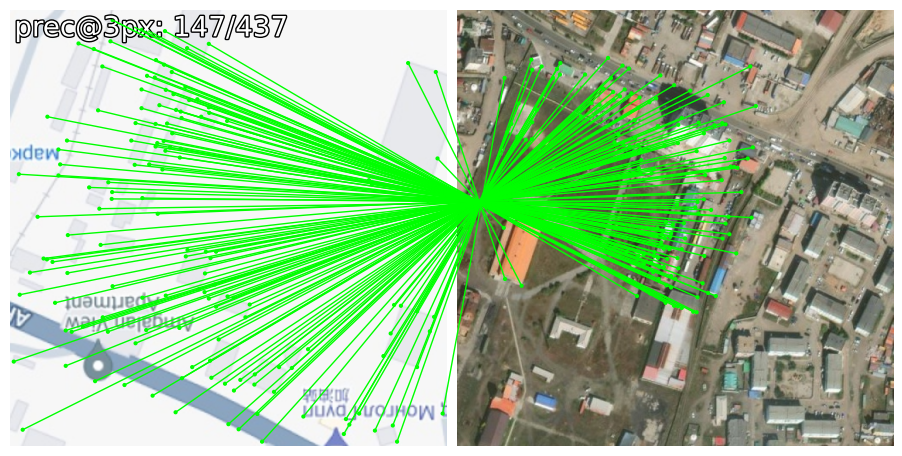

In [5]:
# visualize
axes = visualize.show_images([image0.cpu().numpy(), image1.cpu().numpy()])
visualize.draw_matches(mkpts0, mkpts1, line_colors="lime", line_width=1)
visualize.add_text(0, f'prec@3px: {len(mkpts1)}/{len(points0)}', font_size=20)
plt.show()



## sar-visible image pair matching

In [6]:
# Load example images
image0 = cv2.imread('./assets/sar-visible/L2.jpg')
image1 = cv2.imread('./assets/sar-visible/R2.jpg')

# Convert BGR to RGB
image0 = cv2.cvtColor(image0, cv2.COLOR_BGR2RGB)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

# Convert numpy arrays to torch.Tensor
image0 = torch.from_numpy(image0)
image1 = torch.from_numpy(image1)
num_keypoints = torch.tensor(2048) # Defaults to 2048

# Run inference
points_tensor = model(image0, image1, num_keypoints)
points0 = points_tensor[:, :2]
points1 = points_tensor[:, 2:]

In [7]:
# Mask outliers using RANSAC (Homography or Fundamental Matrix)
inlier_method = 'H' # F: Fundamental Matrix, H: Homography 
if inlier_method == 'F':
    F, inlier_mask = cv2.findFundamentalMat(points0.cpu().numpy(), points1.cpu().numpy(), cv2.USAC_MAGSAC, ransacReprojThreshold=1, maxIters=10000, confidence=0.9999)
elif inlier_method == 'H':
    H_pred, inlier_mask = cv2.findHomography(points0.cpu().numpy(), points1.cpu().numpy(), cv2.USAC_MAGSAC, ransacReprojThreshold=3, maxIters=10000, confidence=0.9999)

inlier_mask = inlier_mask.ravel() > 0
mkpts0 = points0[inlier_mask]
mkpts1 = points1[inlier_mask]

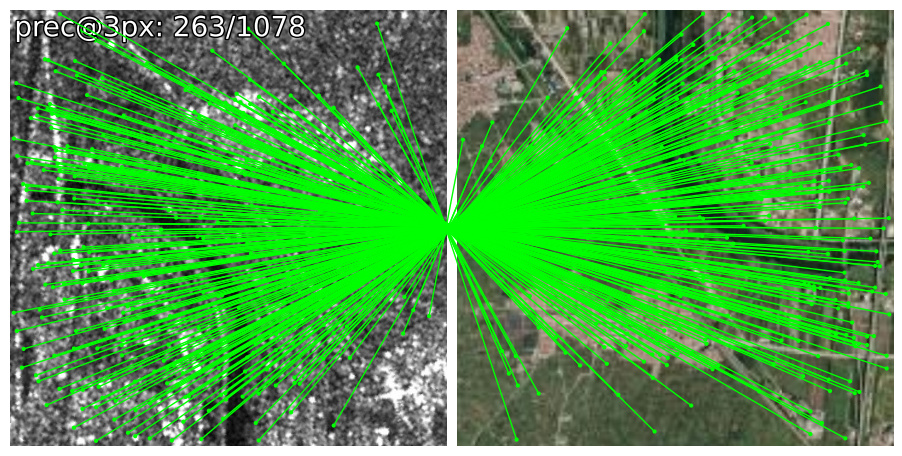

In [8]:
# visualize
axes = visualize.show_images([image0.cpu().numpy(), image1.cpu().numpy()])
visualize.draw_matches(mkpts0, mkpts1, line_colors="lime", line_width=1)
visualize.add_text(0, f'prec@3px: {len(mkpts1)}/{len(points0)}', font_size=20)
plt.show()



In [10]:
# Load example images
image0 = cv2.imread('./m_img_temp/group_1/sample_1/source/sar_transformed.png')
image1 = cv2.imread('./m_img_temp/group_1/sample_1/refer/opt.png')

# Convert BGR to RGB
image0 = cv2.cvtColor(image0, cv2.COLOR_BGR2RGB)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

# Convert numpy arrays to torch.Tensor
image0 = torch.from_numpy(image0)
image1 = torch.from_numpy(image1)
num_keypoints = torch.tensor(2048) # Defaults to 2048

# Run inference
points_tensor = model(image0, image1, num_keypoints)
points0 = points_tensor[:, :2]
points1 = points_tensor[:, 2:]

In [11]:
# Mask outliers using RANSAC (Homography or Fundamental Matrix)
inlier_method = 'H' # F: Fundamental Matrix, H: Homography 
if inlier_method == 'F':
    F, inlier_mask = cv2.findFundamentalMat(points0.cpu().numpy(), points1.cpu().numpy(), cv2.USAC_MAGSAC, ransacReprojThreshold=1, maxIters=10000, confidence=0.9999)
elif inlier_method == 'H':
    H_pred, inlier_mask = cv2.findHomography(points0.cpu().numpy(), points1.cpu().numpy(), cv2.USAC_MAGSAC, ransacReprojThreshold=3, maxIters=10000, confidence=0.9999)

inlier_mask = inlier_mask.ravel() > 0
mkpts0 = points0[inlier_mask]
mkpts1 = points1[inlier_mask]

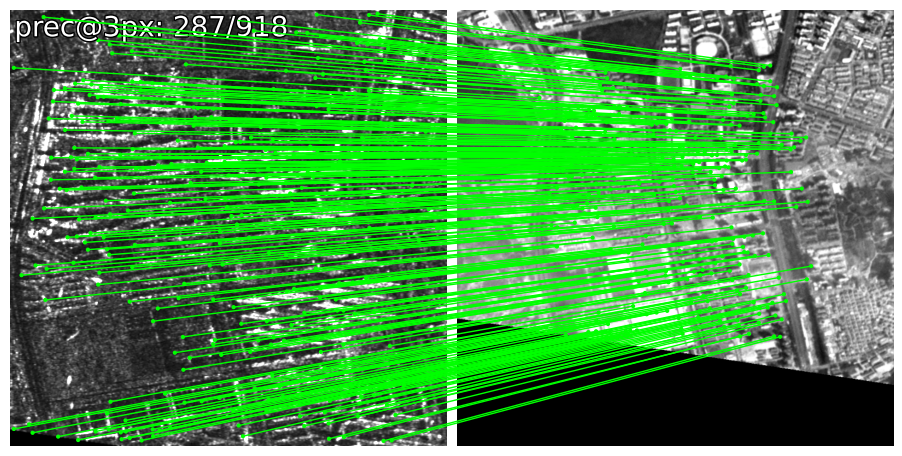

In [12]:
# visualize
axes = visualize.show_images([image0.cpu().numpy(), image1.cpu().numpy()])
visualize.draw_matches(mkpts0, mkpts1, line_colors="lime", line_width=1)
visualize.add_text(0, f'prec@3px: {len(mkpts1)}/{len(points0)}', font_size=20)
plt.show()

In [14]:
import cv2
import torch
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from src.utils.plotting import make_matching_figure


def generate_aligned_chessboard(img1, img2, mkpts0, mkpts1, patch_size=32, save_path=None):
    """
    根据匹配点生成仿射变换矩阵，将图像2进行变换和图像1对齐后，
    将两幅图像切成小patch并间隔拼接成棋盘格图像，可选择保存该图像。

    参数:
    img1 (numpy.ndarray): 第一张图像
    img2 (numpy.ndarray): 第二张图像
    mkpts0 (numpy.ndarray): 第一张图像上的匹配点
    mkpts1 (numpy.ndarray): 第二张图像上的匹配点
    patch_size (int): 小patch的尺寸，默认为32
    save_path (str): 保存棋盘格图像的文件路径，若为None则不保存

    返回:
    numpy.ndarray: 拼接后的棋盘格图像
    """
    # 计算仿射变换矩阵
    M, _ = cv2.estimateAffinePartial2D(mkpts1, mkpts0)
    # 使用仿射变换矩阵将图像2进行变换
    h, w = img1.shape[:2]
    img2_aligned = cv2.warpAffine(img2, M, (w, h))

    # 创建棋盘格图像
    chessboard = np.zeros_like(img1)
    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            if (i // patch_size + j // patch_size) % 2 == 0:
                chessboard[i:i+patch_size, j:j+patch_size] = img1[i:i+patch_size, j:j+patch_size]
            else:
                chessboard[i:i+patch_size, j:j+patch_size] = img2_aligned[i:i+patch_size, j:j+patch_size]

    # 保存棋盘格图像
    if save_path is not None:
        cv2.imwrite(save_path, chessboard)

    return chessboard

# Load the TorchScript model
model = torch.jit.load('./weights/fastmapglue_model.pt')
model.eval()
print("Model loaded successfully!")

# Load example images
img0 = cv2.imread('./m_img_temp/group_1/sample_1/refer/opt.png')
img1 = cv2.imread('./m_img_temp/group_1/sample_1/source/sar_transformed.png')

# Convert BGR to RGB
_img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

# Convert numpy arrays to torch.Tensor
image0 = torch.from_numpy(_img0)
image1 = torch.from_numpy(_img1)
num_keypoints = torch.tensor(2048)

# Run inference
points_tensor = model(image0, image1, num_keypoints)
points0 = points_tensor[:, :2].cpu().numpy()
points1 = points_tensor[:, 2:].cpu().numpy()

# Mask outliers using RANSAC (Homography or Fundamental Matrix)
inlier_method = 'H'
if inlier_method == 'F':
    F, inlier_mask = cv2.findFundamentalMat(points0, points1, cv2.USAC_MAGSAC,
                                            ransacReprojThreshold=1, maxIters=10000, confidence=0.9999)
elif inlier_method == 'H':
    H_pred, inlier_mask = cv2.findHomography(points0, points1, cv2.USAC_MAGSAC,
                                             ransacReprojThreshold=3, maxIters=10000, confidence=0.9999)

inlier_mask = inlier_mask.ravel() > 0
mkpts0 = points0[inlier_mask]
mkpts1 = points1[inlier_mask]

# ---------------- 可视化 ----------------
# 1. 匹配可视化
color = cm.jet(np.linspace(0, 1, len(mkpts0)))
text = [
    'FastMapGlue',
    f'Matches: {len(mkpts0)} / {len(points0)}'
]

fig_match = make_matching_figure(_img0, _img1, mkpts0, mkpts1, color, text=text, dpi=125, path="match_result.png")

# 2. 棋盘格可视化
patch_size = 128
chessboard = generate_aligned_chessboard(_img0, _img1, mkpts0, mkpts1, patch_size, save_path="aligned_chessboard.png")

# 显示结果
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(cv2.imread("match_result.png"), cv2.COLOR_BGR2RGB))
plt.title("Matching Result")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(chessboard)
plt.title("Aligned Chessboard")
plt.axis("off")
plt.show()


Model loaded successfully!


/tmp/ipykernel_2025639/1227334096.py:107: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [1]:
import cv2
import torch
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from src.utils.plotting import make_matching_figure

# 设置matplotlib后端（解决显示问题）
import matplotlib
matplotlib.use('Agg')  # 使用非交互式后端
# 如果在Jupyter notebook中，可以使用：
# %matplotlib inline

def generate_aligned_chessboard(img1, img2, mkpts0, mkpts1, patch_size=32, save_path=None):
    """
    根据匹配点生成仿射变换矩阵，将图像2进行变换和图像1对齐后，
    将两幅图像切成小patch并间隔拼接成棋盘格图像，可选择保存该图像。

    参数:
    img1 (numpy.ndarray): 第一张图像
    img2 (numpy.ndarray): 第二张图像
    mkpts0 (numpy.ndarray): 第一张图像上的匹配点
    mkpts1 (numpy.ndarray): 第二张图像上的匹配点
    patch_size (int): 小patch的尺寸，默认为32
    save_path (str): 保存棋盘格图像的文件路径，若为None则不保存

    返回:
    numpy.ndarray: 拼接后的棋盘格图像
    """
    # 检查匹配点数量
    if len(mkpts0) < 3 or len(mkpts1) < 3:
        print(f"Warning: 匹配点数量太少 ({len(mkpts0)} 个)，无法进行可靠的仿射变换")
        return img1  # 返回原图像
    
    try:
        # 计算仿射变换矩阵
        M, _ = cv2.estimateAffinePartial2D(mkpts1, mkpts0)
        
        if M is None:
            print("Warning: 无法计算仿射变换矩阵，返回原图像")
            return img1
            
        # 使用仿射变换矩阵将图像2进行变换
        h, w = img1.shape[:2]
        img2_aligned = cv2.warpAffine(img2, M, (w, h))

        # 创建棋盘格图像
        chessboard = np.zeros_like(img1)
        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                if (i // patch_size + j // patch_size) % 2 == 0:
                    chessboard[i:i+patch_size, j:j+patch_size] = img1[i:i+patch_size, j:j+patch_size]
                else:
                    chessboard[i:i+patch_size, j:j+patch_size] = img2_aligned[i:i+patch_size, j:j+patch_size]

        # 保存棋盘格图像
        if save_path is not None:
            cv2.imwrite(save_path, chessboard)
            print(f"棋盘格图像已保存到: {save_path}")

        return chessboard
    
    except Exception as e:
        print(f"生成棋盘格时出错: {e}")
        return img1

def main():
    try:
        # Load the TorchScript model
        model = torch.jit.load('./weights/fastmapglue_model.pt')
        model.eval()
        print("Model loaded successfully!")

        # Load example images
        img0 = cv2.imread('./m_img_temp/group_2/sample_1/refer/opt.png')
        img1 = cv2.imread('./m_img_temp/group_2/sample_1/source/sar_transformed.png')

        if img0 is None or img1 is None:
            print("Error: 无法加载图像文件，请检查文件路径")
            return

        # Convert BGR to RGB
        _img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
        _img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

        # Convert numpy arrays to torch.Tensor
        image0 = torch.from_numpy(_img0)
        image1 = torch.from_numpy(_img1)
        num_keypoints = torch.tensor(2048)

        # Run inference
        print("Running inference...")
        points_tensor = model(image0, image1, num_keypoints)
        points0 = points_tensor[:, :2].cpu().numpy()
        points1 = points_tensor[:, 2:].cpu().numpy()
        print(f"Found {len(points0)} initial matches")

        # Mask outliers using RANSAC (Homography or Fundamental Matrix)
        inlier_method = 'H'
        if inlier_method == 'F':
            F, inlier_mask = cv2.findFundamentalMat(points0, points1, cv2.USAC_MAGSAC,
                                                    ransacReprojThreshold=1, maxIters=10000, confidence=0.9999)
        elif inlier_method == 'H':
            H_pred, inlier_mask = cv2.findHomography(points0, points1, cv2.USAC_MAGSAC,
                                                     ransacReprojThreshold=3, maxIters=10000, confidence=0.9999)

        if inlier_mask is not None:
            inlier_mask = inlier_mask.ravel() > 0
            mkpts0 = points0[inlier_mask]
            mkpts1 = points1[inlier_mask]
            print(f"After RANSAC filtering: {len(mkpts0)} inlier matches")
        else:
            print("Warning: RANSAC failed, using all matches")
            mkpts0 = points0
            mkpts1 = points1

        # ---------------- 可视化 ----------------
        # 1. 匹配可视化
        if len(mkpts0) > 0:
            color = cm.jet(np.linspace(0, 1, len(mkpts0)))
            text = [
                'FastMapGlue',
                f'Matches: {len(mkpts0)} / {len(points0)}'
            ]

            try:
                fig_match = make_matching_figure(_img0, _img1, mkpts0, mkpts1, color, text=text, dpi=125, path="match_result.png")
                print("匹配结果已保存到: match_result.png")
            except Exception as e:
                print(f"保存匹配结果时出错: {e}")

            # 2. 棋盘格可视化
            patch_size = 512
            chessboard = generate_aligned_chessboard(_img0, _img1, mkpts0, mkpts1, patch_size, save_path="aligned_chessboard.png")

            # 创建并保存可视化结果（不使用plt.show()）
            try:
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # 左侧显示匹配结果
                try:
                    match_img = cv2.imread("match_result.png")
                    if match_img is not None:
                        match_img_rgb = cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB)
                        axes[0].imshow(match_img_rgb)
                        axes[0].set_title("Matching Result")
                        axes[0].axis("off")
                    else:
                        axes[0].text(0.5, 0.5, "匹配结果图像未找到", ha='center', va='center', transform=axes[0].transAxes)
                except Exception as e:
                    print(f"加载匹配结果图像时出错: {e}")

                # 右侧显示棋盘格结果
                axes[1].imshow(chessboard)
                axes[1].set_title("Aligned Chessboard")
                axes[1].axis("off")
                
                plt.tight_layout()
                plt.savefig("final_result.png", dpi=150, bbox_inches='tight')
                print("最终结果已保存到: final_result.png")
                plt.close()  # 关闭图像释放内存
                
            except Exception as e:
                print(f"保存最终结果时出错: {e}")

        else:
            print("Warning: 没有找到有效的匹配点")

    except Exception as e:
        print(f"程序执行出错: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

# 替代方案：如果在Jupyter notebook中运行，可以使用以下代码
def jupyter_display():
    """在Jupyter notebook中显示结果的函数"""
    try:
        from IPython.display import Image, display
        import matplotlib.pyplot as plt
        
        # 显示保存的图像
        print("匹配结果:")
        display(Image("match_result.png"))
        
        print("棋盘格对齐结果:")
        display(Image("aligned_chessboard.png"))
        
        print("完整结果:")
        display(Image("final_result.png"))
        
    except ImportError:
        print("不在Jupyter环境中，图像已保存到文件")

# 在Jupyter notebook中调用：jupyter_display()

Model loaded successfully!
Running inference...
Found 1157 initial matches
After RANSAC filtering: 28 inlier matches
匹配结果已保存到: match_result.png
棋盘格图像已保存到: aligned_chessboard.png
最终结果已保存到: final_result.png
